**Activate User Environment**

In [1]:
import Pkg; Pkg.activate("/Users/heerakbanerjee/Documents/Newtrinos.jl/devenv/");


  Activating project at `~/Documents/Newtrinos.jl/devenv`


**Load Packages**

In [2]:
#using Revise
using Newtrinos
#using CairoMakie
using Plots
using StatsBase

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x6f81365c6046ff2f, 0x6fd35e4ce9a5b3e0, 0x48da33dbf1bc8730, 0xc86255db30823e61, 0xf421b919db82aaad, 0x2c49138935b3d472, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), ADTypes.NoAutoDiff())
[ Info: (cuinit = HeterogeneousComputing.CPUnit(), precision = Float64, rng = Random123.Philox4x{UInt64, 10}(0x6f81365c6046ff2f, 0x6fd35e4ce9a5b3e0, 0x48da33dbf1bc8730, 0xc86255db30823e61, 0xf421b919db82aaad, 0x2c49138935b3d472, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), ad = ADTypes.AutoForwardDiff())


In [ ]:
# Configure both experiments
coherent_csi = Newtrinos.coherent_csi.configure()
coherent_lAr = Newtrinos.coherent_lAr.configure()

csi_assets= coherent_csi.assets
lAr_assets= coherent_lAr.assets

function plot_ffsq_vs_er(assets, ffsq; drn=0.6, n_rn=5)
    er = assets.er_centers .* 1e-3 # Convert to MeV
    isotopes = assets.isotopes
    for iso in isotopes
        mn = iso.mass
        rn_central = iso.Rn_nom
        rn_grid = range(rn_central - drn, rn_central + drn, length=n_rn)
        plt = plot()
        for rn in rn_grid
            plot!(plt, er.*1e3, [ffsq(e, mn, rn) for e in er], label="rn=$(round(rn, digits=2)) fm", xscale=:log10)
        end
        xlabel!(plt, "Recoil Energy (keV)")
        ylabel!(plt, "Form Factor Squared")
        title!(plt, "Isotope: $(iso.Rn_key), mn=$(mn) MeV, rn₀=$(rn_central) fm")
        display(plt)
    end
end


#

[ Info: Flux is not fully configured yet.
[ Info: Loading and binning CsI data
[ Info: Configuring Flux
[ Info: Configuring CEvNS cross-section assets
[ Info: Configured COHERENT CsI module.
[ Info: Loading coherent lAr data
[ Info: Configuring CEvNS cross-section assets


plot_ffsq_vs_er (generic function with 1 method)

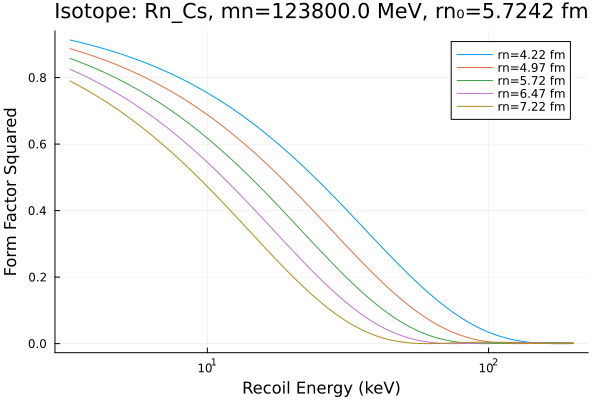

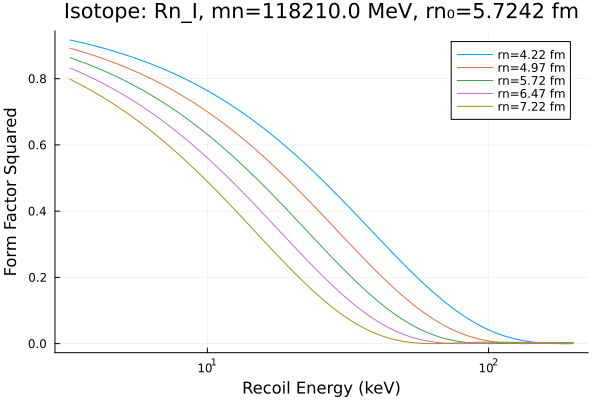

In [13]:
plot_ffsq_vs_er(coherent_csi.assets, Newtrinos.cevns_xsec.ffsq; drn=1.5)

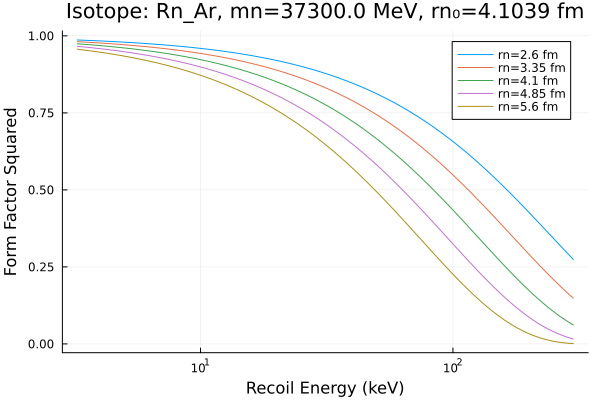

In [14]:
plot_ffsq_vs_er(coherent_lAr.assets, Newtrinos.cevns_xsec.ffsq; drn=1.5)

**Test CsI Dataset and Prediction**

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:194
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:126


Total signal counts: 435.6891967518653
Total BRN background counts: 171.0
Total NIN counts: 171.0
Total SS background counts: 3889.0
Total observed counts: 4170


┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:127
┌ Info: Configuring CEvNS cross-section assets
└ @ Newtrinos.cevns_xsec /Users/heerakbanerjee/Documents/Newtrinos.jl/src/physics/cevns_xsec.jl:69
┌ Info: Configured COHERENT CsI module.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:46


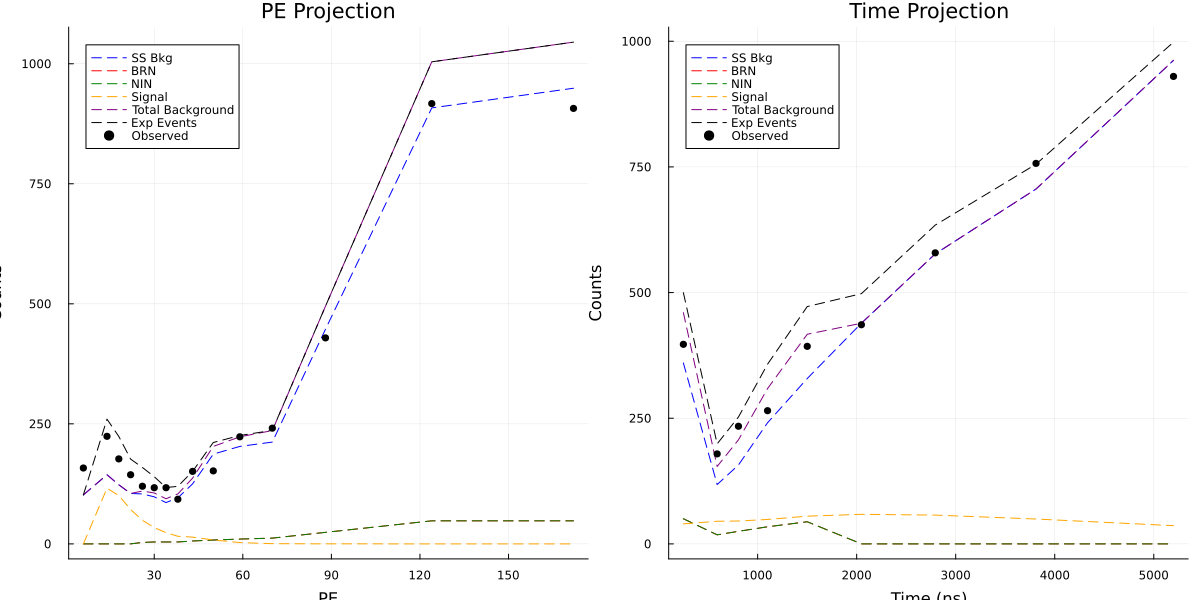

In [12]:

# Configure the COHERENT_CSI experiment
coherent_csi = Newtrinos.coherent_csi.configure()

# Access the configured components
physics = coherent_csi.physics
params = Newtrinos.get_params(coherent_csi)
assets = coherent_csi.assets

# Compute the expected signal and backgrounds
signal = Newtrinos.coherent_csi.get_expected(params, physics, assets)  # (n_out, n_time)
#@info "Computed expected signal."
brn, nin, ssBkg = Newtrinos.coherent_csi.get_backgrounds(params, assets)  # (n_out, n_time)
total_bkg = brn .+ nin .+ ssBkg  # (n_out, n_time)
#@info "Computed expected backgrounds."
exp_events = signal .+ total_bkg  # (n_out, n_time)
#@info "Computed expected total events."
# Observed data
observed = assets.observed  # (n_out, n_time)

# Compute projections
PE_bins = assets.out_centers
time_bins = assets.time_bins

# PE projection: sum over time bins
signal_PE = sum(signal, dims=2)[:, 1]
brn_PE = sum(brn, dims=2)[:, 1]
nin_PE = sum(nin, dims=2)[:, 1]
ssBkg_PE = sum(ssBkg, dims=2)[:, 1]
total_bkg_PE = sum(total_bkg, dims=2)[:, 1]
exp_events_PE = sum(exp_events, dims=2)[:, 1]
observed_PE = sum(observed, dims=2)[:, 1]

# Time projection: sum over PE bins
signal_time = sum(signal, dims=1)[1, :]
brn_time = sum(brn, dims=1)[1, :]
nin_time = sum(nin, dims=1)[1, :]
ssBkg_time = sum(ssBkg, dims=1)[1, :]
total_bkg_time = sum(total_bkg, dims=1)[1, :]
exp_events_time = sum(exp_events, dims=1)[1, :]
observed_time = sum(observed, dims=1)[1, :]

# Print total counts
println("Total signal counts: ", sum(signal))
println("Total BRN background counts: ", sum(brn))
println("Total NIN counts: ", sum(nin))
println("Total SS background counts: ", sum(ssBkg))
println("Total observed counts: ", sum(observed))

# Create the (1, 2) subplot layout
plot1 = Plots.plot(PE_bins, ssBkg_PE; label="SS Bkg", linestyle=:dash, color=:blue, xlabel="PE", ylabel="Counts", title="PE Projection")
Plots.plot!(PE_bins, brn_PE; label="BRN", linestyle=:dash, color=:red)
Plots.plot!(PE_bins, nin_PE; label="NIN", linestyle=:dash, color=:green)
Plots.plot!(PE_bins, signal_PE; label="Signal", linestyle=:dash, color=:orange)
Plots.plot!(PE_bins, total_bkg_PE; label="Total Background", linestyle=:dash, color=:purple)
Plots.plot!(PE_bins, exp_events_PE; label="Exp Events", linestyle=:dash, color=:black)
Plots.scatter!(PE_bins, observed_PE; label="Observed", color=:black)

plot2 = Plots.plot(time_bins, ssBkg_time; label="SS Bkg", linestyle=:dash, color=:blue, xlabel="Time (ns)", ylabel="Counts", title="Time Projection")
Plots.plot!(time_bins, brn_time; label="BRN", linestyle=:dash, color=:red)
Plots.plot!(time_bins, nin_time; label="NIN", linestyle=:dash, color=:green)
Plots.plot!(time_bins, signal_time; label="Signal", linestyle=:dash, color=:orange)
Plots.plot!(time_bins, total_bkg_time; label="Total Background", linestyle=:dash, color=:purple)
Plots.plot!(time_bins, exp_events_time; label="Exp Events", linestyle=:dash, color=:black)
Plots.scatter!(time_bins, observed_time; label="Observed", color=:black)

# Combine the two plots into a single layout
Plots.plot(plot1, plot2, layout=(1, 2), size=(1200, 600))

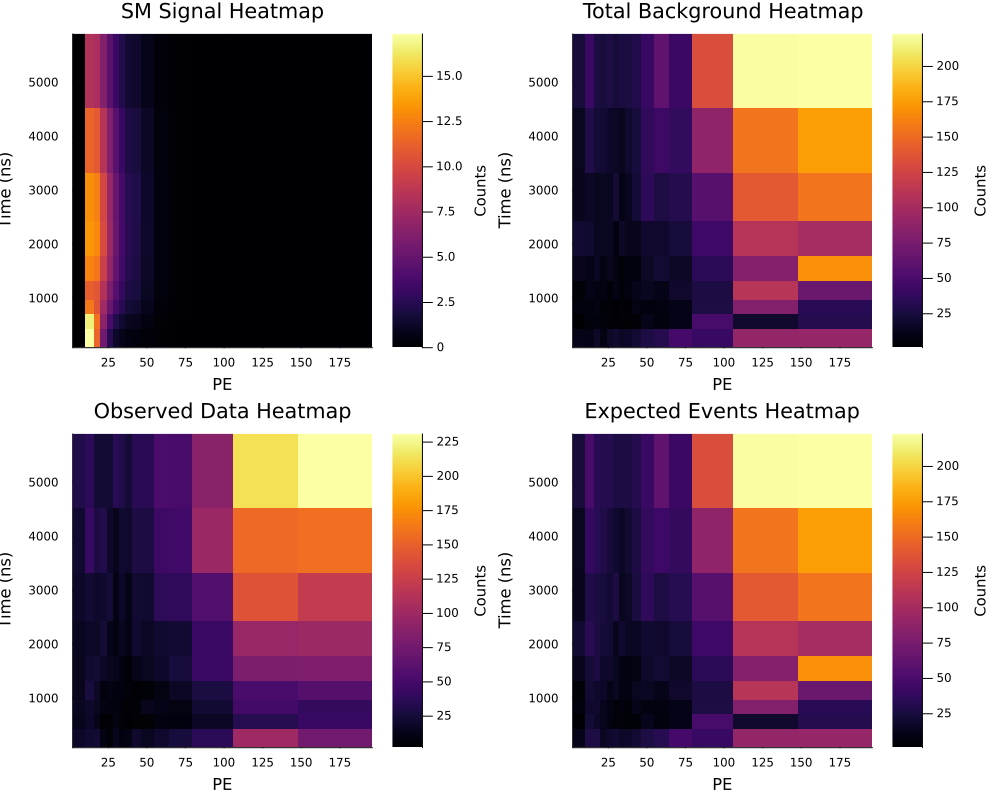

In [14]:
p1= Plots.heatmap(PE_bins, time_bins, signal'; xlabel="PE", ylabel="Time (ns)", title="SM Signal Heatmap", colorbar_title="Counts")
p2= Plots.heatmap(PE_bins, time_bins, total_bkg'; xlabel="PE", ylabel="Time (ns)", title="Total Background Heatmap", colorbar_title="Counts")
p3= Plots.heatmap(PE_bins, time_bins, observed'; xlabel="PE", ylabel="Time (ns)", title="Observed Data Heatmap", colorbar_title="Counts")
p4= Plots.heatmap(PE_bins, time_bins, exp_events'; xlabel="PE", ylabel="Time (ns)", title="Expected Events Heatmap", colorbar_title="Counts")

Plots.plot(p1, p2, p3, p4, layout=(2, 2), size=(1000, 800))

**Test l-Ar Dataset and Prediction**

Total signal counts: 127.11966586590307

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86
┌ Info: Configuring CEvNS cross-section assets
└ @ Newtrinos.cevns_xsec /Users/heerakbanerjee/Documents/Newtrinos.jl/src/physics/cevns_xsec.jl:69


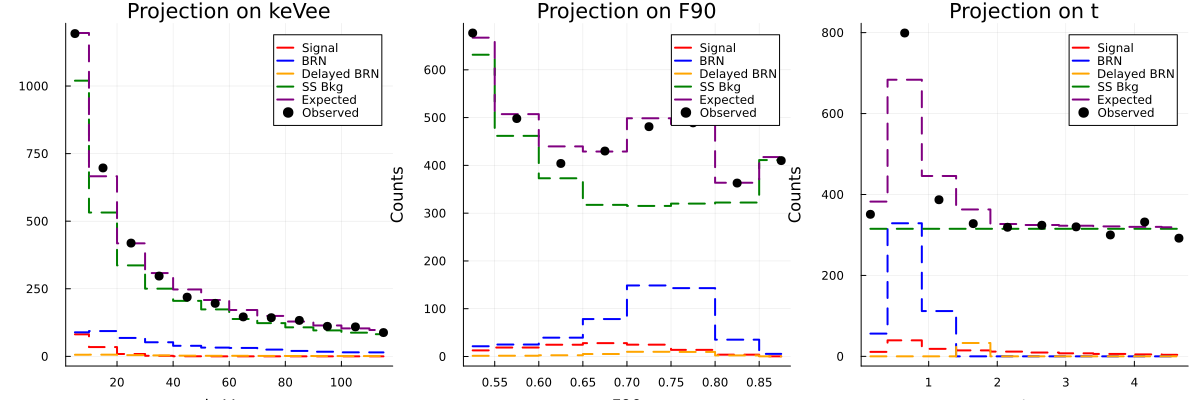


Total BRN background counts: 496.99999307
Total Delayed BRN background counts: 33.00001642
Total SS background counts: 3152.0001600000032
Total observed counts: 3752


In [ ]:
# Configure the COHERENT_lAr experiment
coherent_lAr = Newtrinos.coherent_lAr.configure()

# Access the configured components
physics = coherent_lAr.physics
params = Newtrinos.get_params(coherent_lAr)
assets = coherent_lAr.assets

# Signal and Backgrounds
expected_counts = Newtrinos.coherent_lAr.get_expected(params, physics, assets)
bkg_brn, bkg_delbrn, bkg_ss_bkg = Newtrinos.coherent_lAr.get_backgrounds(params, assets)
total_bkg = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg
# Cumulative expected signal + backgrounds
signal_cum = bkg_brn .+ bkg_delbrn .+ bkg_ss_bkg .+ expected_counts

# Observed data
observed_counts = assets.observed

# Define the second subplot matrix: Projections on keVee, F90, and t
# Projections are computed by summing over the appropriate bins
keVee_centers = assets.out_centers
f90_centers = assets.f90_centers
timing_centers = assets.timing_centers

# Reshape the signal and background arrays to match the binning structure
n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)
# Print total counts
println("Total signal counts: ", sum(expected_counts))
println("Total BRN background counts: ", sum(bkg_brn))
println("Total Delayed BRN background counts: ", sum(bkg_delbrn))
println("Total SS background counts: ", sum(bkg_ss_bkg))
println("Total observed counts: ", sum(observed_counts))

# Stack the bin centers and counts into separate arrays for each component
data_signal = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   expected_counts)

data_expected = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                      repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                      repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                      signal_cum)

data_brn = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                bkg_brn)

data_delbrn = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   bkg_delbrn)

data_ss_bkg = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                   repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                   repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                   bkg_ss_bkg)

data_observed = hcat(repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
                     repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
                     repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
                     observed_counts)

# Function to compute projections
function compute_projection(data, bin_centers, col_index)
    proj = zeros(length(bin_centers))
    for i in 1:length(bin_centers)
        proj[i] = sum(data[data[:, col_index] .== bin_centers[i], 4])
    end
    return proj
end

# Compute projections for each component
proj_keVee_signal = compute_projection(data_signal, keVee_centers, 1)
proj_keVee_brn = compute_projection(data_brn, keVee_centers, 1)
proj_keVee_delbrn = compute_projection(data_delbrn, keVee_centers, 1)
proj_keVee_ss_bkg = compute_projection(data_ss_bkg, keVee_centers, 1)
proj_keVee_observed = compute_projection(data_observed, keVee_centers, 1)
proj_keVee_expected = compute_projection(data_expected, keVee_centers, 1)

proj_F90_signal = compute_projection(data_signal, f90_centers, 2)
proj_F90_brn = compute_projection(data_brn, f90_centers, 2)
proj_F90_delbrn = compute_projection(data_delbrn, f90_centers, 2)
proj_F90_ss_bkg = compute_projection(data_ss_bkg, f90_centers, 2)
proj_F90_observed = compute_projection(data_observed, f90_centers, 2)
proj_F90_expected = compute_projection(data_expected, f90_centers, 2)

proj_t_signal = compute_projection(data_signal, timing_centers, 3)
proj_t_brn = compute_projection(data_brn, timing_centers, 3)
proj_t_delbrn = compute_projection(data_delbrn, timing_centers, 3)
proj_t_ss_bkg = compute_projection(data_ss_bkg, timing_centers, 3)
proj_t_observed = compute_projection(data_observed, timing_centers, 3)
proj_t_expected = compute_projection(data_expected, timing_centers, 3)

# Plot the projections with step-like visualization
plt4 = Plots.plot(keVee_centers, proj_keVee_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="keVee", ylabel="Counts", title="Projection on keVee")
Plots.plot!(plt4, keVee_centers, proj_keVee_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
Plots.plot!(plt4, keVee_centers, proj_keVee_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

plt5 = Plots.plot(f90_centers, proj_F90_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="F90", ylabel="Counts", title="Projection on F90")
Plots.plot!(plt5, f90_centers, proj_F90_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
Plots.plot!(plt5, f90_centers, proj_F90_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

plt6 = Plots.plot(timing_centers, proj_t_signal, label="Signal", seriestype=:stepmid, color=:red, lw=2, linestyle=:dash, xlabel="t", ylabel="Counts", title="Projection on t")
Plots.plot!(plt6, timing_centers, proj_t_brn, label="BRN", seriestype=:stepmid, color=:blue, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_delbrn, label="Delayed BRN", seriestype=:stepmid, color=:orange, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_ss_bkg, label="SS Bkg", seriestype=:stepmid, color=:green, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_expected, label="Expected", seriestype=:stepmid, color=:purple, lw=2, linestyle=:dash)
Plots.plot!(plt6, timing_centers, proj_t_observed, label="Observed", seriestype=:scatter, marker=:circle, markersize=5, color=:black)

# Combine the plots into a single layout
Plots.plot(plt4, plt5, plt6, layout=(1,3), size=(1200,400))
display(current())

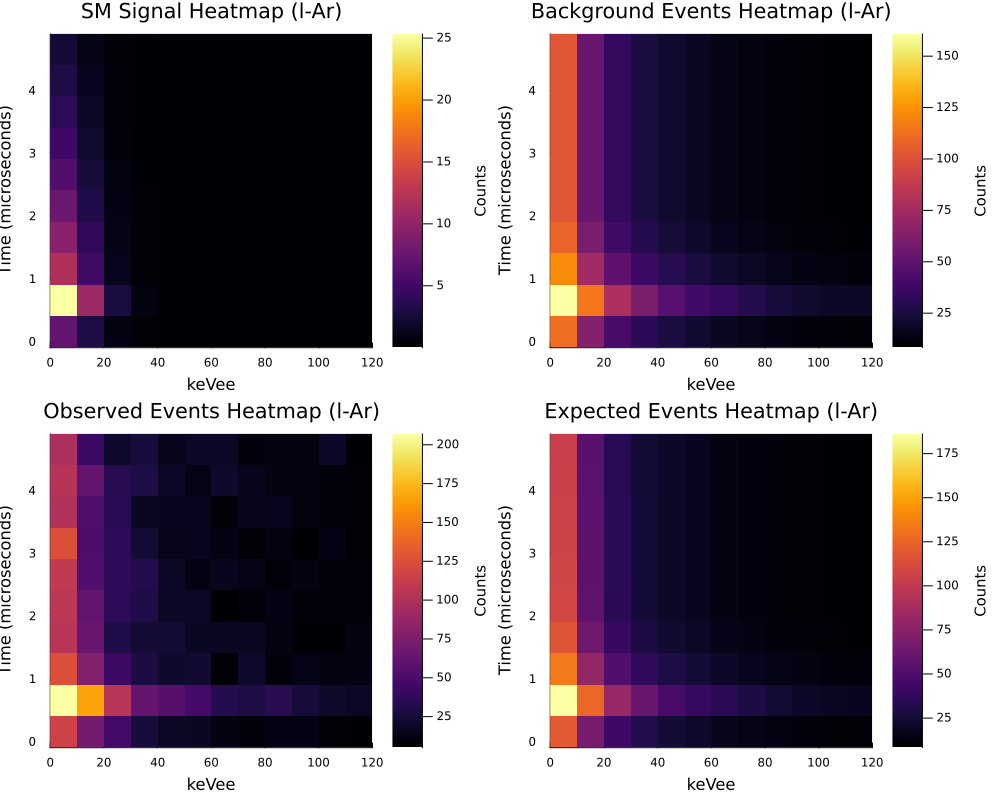

In [ ]:
# Reshape expected_counts to (keVee, F90, time)
expected_reshaped = permutedims(
    reshape(signal_cum, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)
observed_reshaped = permutedims(
    reshape(observed_counts, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)
signal_reshaped = permutedims(
    reshape(expected_counts, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)
bkg_reshaped = permutedims(
    reshape(total_bkg, n_timing_bins, n_f90_bins, n_keVee_bins),
    (3, 2, 1)
)

# Sum over F90 to get (keVee, time) matrix
signal_keVee_time = sum(signal_reshaped, dims=2)[:, 1, :]
observed_keVee_time = sum(observed_reshaped, dims=2)[:, 1, :]
expected_keVee_time = sum(expected_reshaped, dims=2)[:, 1, :]
bkg_keVee_time = sum(bkg_reshaped, dims=2)[:, 1, :]

# Plot heatmap: X=keVee, Y=time

p1 = Plots.heatmap(
    keVee_centers,
    timing_centers,
    observed_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="Observed Events Heatmap (l-Ar)",
    colorbar_title="Counts"
)

p2= Plots.heatmap(
    keVee_centers,
    timing_centers,
    expected_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="Expected Events Heatmap (l-Ar)",
    colorbar_title="Counts"
)

p3= Plots.heatmap(
    keVee_centers,
    timing_centers,
    signal_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="SM Signal Heatmap (l-Ar)",
    colorbar_title="Counts"
)

p4= Plots.heatmap(
    keVee_centers,
    timing_centers,
    bkg_keVee_time',
    xlabel="keVee",
    ylabel="Time (microseconds)",
    title="Background Events Heatmap (l-Ar)",
    colorbar_title="Counts"
)

Plots.plot(p3, p4, p1, p2, layout=(2,2), size=(1000,800))

display(current())

**Check Parameter Dependence**

*CsI Detector*

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:193
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:125


No NaNs for cevns_xsec_a = -0.5
No NaNs for cevns_xsec_a = 0.0
No NaNs for cevns_xsec_a = 0.5
vals_nom[1:10] = [0.0, 17.34761133536316, 11.383097153223234, 5.414104321542591, 2.4319492223598855, 1.2408980013560515, 0.7409393934571515, 0.47794048471711986, 0.41963411107018966, 0.24132914191119473]
sum(vals_nom) = 435.6891967518653
No NaNs for cevns_xsec_b = -500.0
No NaNs for cevns_xsec_b = 0.0
No NaNs for cevns_xsec_b = 500.0
vals_nom[1:10] = [0.0, 17.34761133536316, 11.383097153223234, 5.414104321542591, 2.4319492223598855, 1.2408980013560515, 0.7409393934571515, 0.47794048471711986, 0.41963411107018966, 0.24132914191119473]
sum(vals_nom) = 435.6891967518653
No NaNs for cevns_xsec_c = -0.5
No NaNs for cevns_xsec_c = 0.0
No NaNs for cevns_xsec_c = 0.5
vals_nom[1:10] = [0.0, 17.34761133536316, 11.383097153223234, 5.414104321542591, 2.4319492223598855, 1.2408980013560515, 0.7409393934571515, 0.47794048471711986, 0.41963411107018966, 0.24132914191119473]
sum(vals_nom) = 435.6891967518653


┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:126
┌ Info: Configuring CEvNS cross-section assets
└ @ Newtrinos.cevns_xsec /Users/heerakbanerjee/Documents/Newtrinos.jl/src/physics/cevns_xsec.jl:69
┌ Info: Configured COHERENT CsI module.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:45


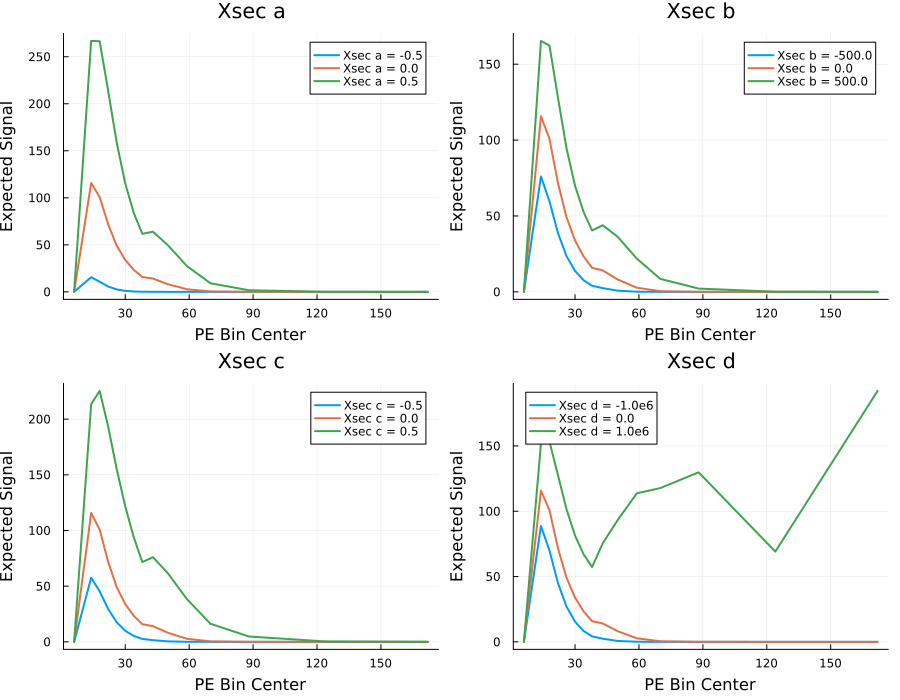

In [ ]:
# Check dependence of expected signal PE projection on cevns_xsec parameters (CsI)

coherent_csi = Newtrinos.coherent_csi.configure()
physics = coherent_csi.physics
assets = coherent_csi.assets
p_nom = Newtrinos.get_params(coherent_csi)
out_centers = assets.out_centers

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 5e2, 0.5, 1e6]  # scaling for a, b, c, d

plots = []
for (i, sym) in enumerate(param_syms)
    plt = Plots.plot()
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        p = merge(p, (sym => val * param_scales[i],))
        vals = Newtrinos.coherent_csi.get_expected(p, physics, assets)
        vals_PE = sum(vals, dims=2)[:, 1]  # Project to PE
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $(val * param_scales[i])"
        Plots.plot!(plt, out_centers, vals_PE, label=label_str, lw=2)
    end
    Plots.plot!(plt, xlabel="PE Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
    vals_nom = Newtrinos.coherent_csi.get_expected(p_nom, physics, assets)
    @show vals_nom[1:10]
    @show sum(vals_nom)
end
Plots.plot(plots..., layout=(2,2), size=(900,700))

*Liquid-Ar Detector*

expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86
┌ Info: Configuring CEvNS cross-section assets
└ @ Newtrinos.cevns_xsec /Users/heerakbanerjee/Documents/Newtrinos.jl/src/physics/cevns_xsec.jl:69



sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307
expected_counts_nom[1:10] = [0.7134986829631883, 2.561116392778422, 1.2038711515239096, 0.9558205498340436, 0.7639001848830121, 0.6106604027315748, 0.4882343952139328, 0.388273913149741, 0.3082100658036578, 0.24600292767520784]
sum(expected_counts_nom) = 127.11966586590307


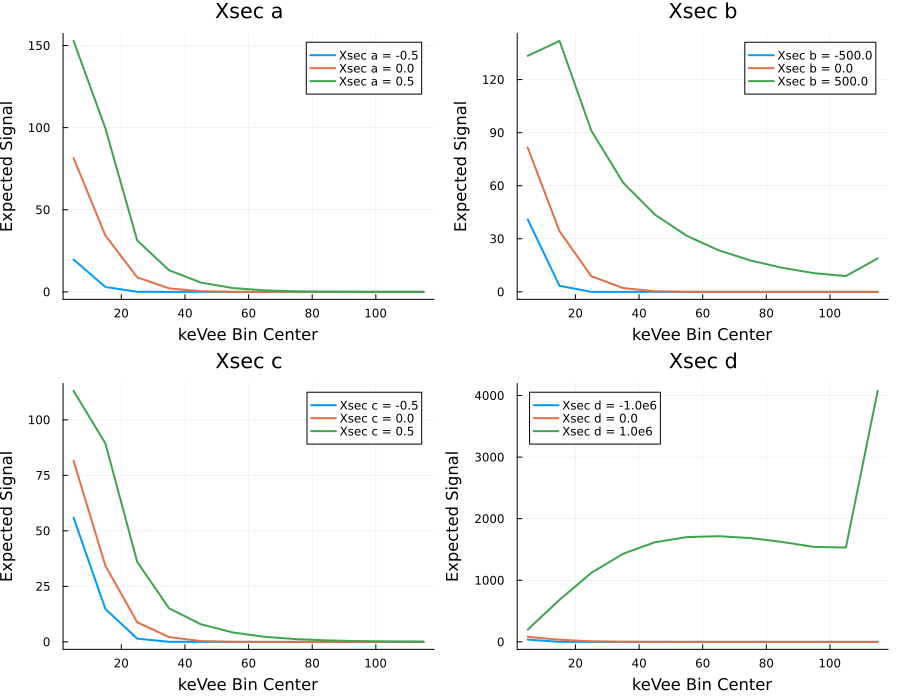

In [ ]:
# Check dependence of expected signal PE projection on cevns_xsec parameters (l-Ar)

coherent_lAr = Newtrinos.coherent_lAr.configure()
physics = coherent_lAr.physics
assets = coherent_lAr.assets
p_nom = Newtrinos.get_params(coherent_lAr)
keVee_centers = assets.out_centers
f90_centers = assets.f90_centers
timing_centers = assets.timing_centers

n_keVee_bins = length(keVee_centers)
n_f90_bins = length(f90_centers)
n_timing_bins = length(timing_centers)

function compute_projection(data, bin_centers, col_index)
    proj = zeros(length(bin_centers))
    for i in 1:length(bin_centers)
        proj[i] = sum(data[data[:, col_index] .== bin_centers[i], 4])
    end
    return proj
end

param_syms = [:cevns_xsec_a, :cevns_xsec_b, :cevns_xsec_c, :cevns_xsec_d]
param_labels = ["Xsec a", "Xsec b", "Xsec c", "Xsec d"]
param_scales = [0.5, 5e2, 0.5, 1e6]

plots = []
for (i, sym) in enumerate(param_syms)
    plt = Plots.plot()
    for val in [-1.0, 0.0, 1.0]
        p = deepcopy(p_nom)
        p = merge(p, (sym => val * param_scales[i],))
        expected_counts = Newtrinos.coherent_lAr.get_expected(p, physics, assets)
        data_signal = hcat(
            repeat(keVee_centers, inner=n_f90_bins * n_timing_bins),
            repeat(f90_centers, inner=n_timing_bins, outer=n_keVee_bins),
            repeat(timing_centers, outer=n_keVee_bins * n_f90_bins),
            expected_counts
        )
        proj_keVee_signal = compute_projection(data_signal, keVee_centers, 1)
        label_str = param_scales[i] == 1 ? "$(param_labels[i]) = $val" : "$(param_labels[i]) = $(val * param_scales[i])"
        Plots.plot!(plt, keVee_centers, proj_keVee_signal, label=label_str, lw=2)
    end
    Plots.plot!(plt, xlabel="keVee Bin Center", ylabel="Expected Signal", title=param_labels[i])
    push!(plots, plt)
    expected_counts_nom = Newtrinos.coherent_lAr.get_expected(p_nom, physics, assets)
    @show expected_counts_nom[1:10]
    @show sum(expected_counts_nom)
end
Plots.plot(plots..., layout=(2,2), size=(900,700))

┌ Info: Flux is not fully configured yet.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:194
┌ Info: Loading and binning CsI data
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:126
┌ Info: Configuring Flux
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:127
┌ Info: Configuring CEvNS cross-section assets
└ @ Newtrinos.cevns_xsec /Users/heerakbanerjee/Documents/Newtrinos.jl/src/physics/cevns_xsec.jl:69
┌ Info: Configured COHERENT CsI module.
└ @ Newtrinos.coherent_csi /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_csi.jl:46
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = .

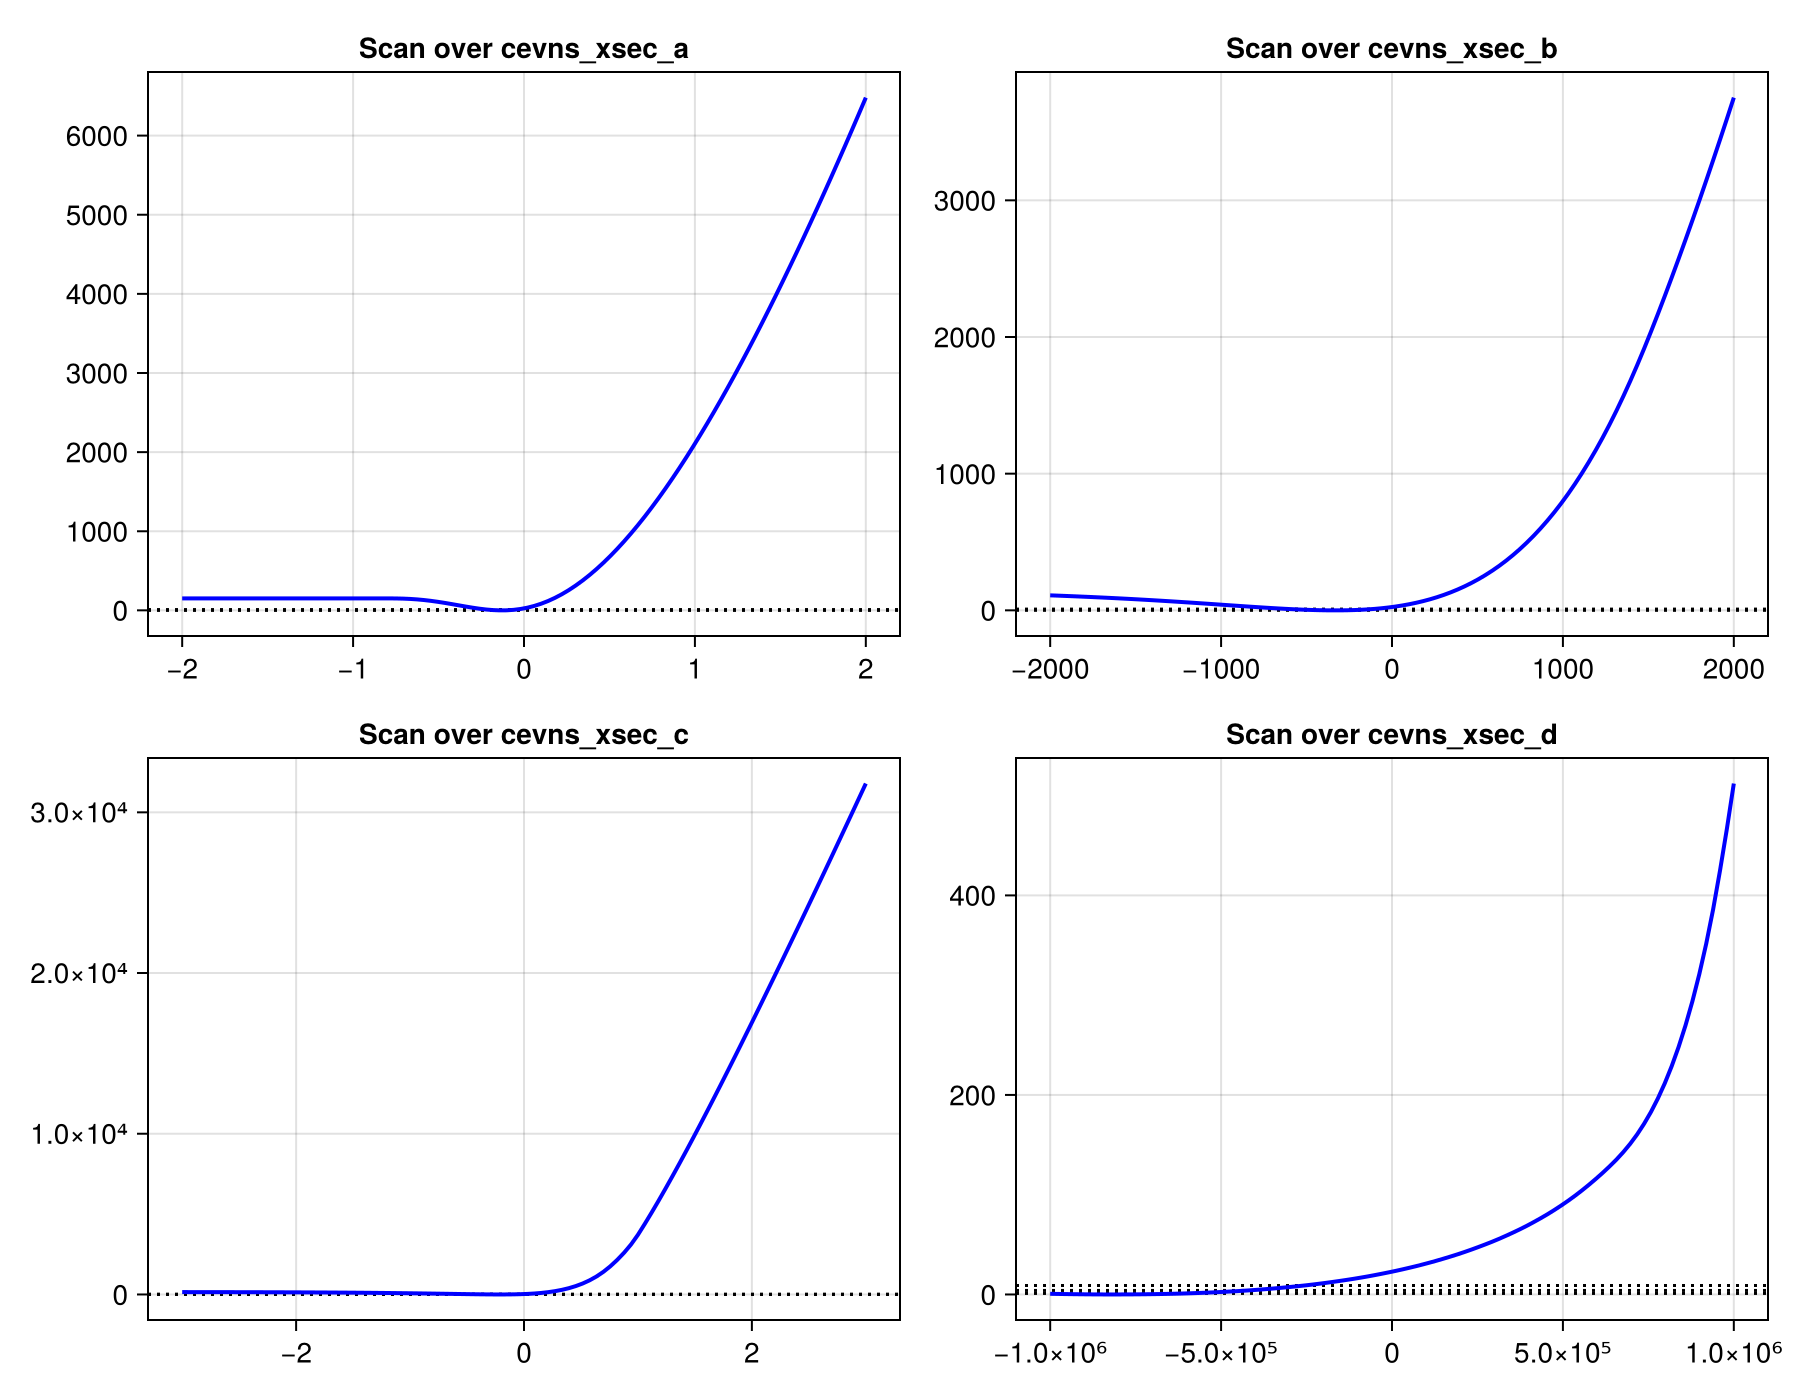

In [8]:
using CairoMakie

coherent_csi = Newtrinos.coherent_csi.configure()
#coherent_lAr = Newtrinos.coherent_lAr.configure()
experiments = (; coherent_csi)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)


scan_params = [
    (:cevns_xsec_a, 100, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 100, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 100, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 100, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

In [9]:
using BAT
prior = distprod(;priors...)
bestfit = Newtrinos.find_mle(likelihood, prior, p)

┌ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x2fa10295590e141e, 0x7803558ce954af30, 0xa351d3e1540813df, 0xc44bbd782c5fe3bd, 0x9efb189ff7ce20e0, 0x9d237c942ca8202d, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())
└ @ BAT /Users/heerakbanerjee/.julia/packages/BAT/miu9X/src/algotypes/bat_context.jl:121
┌ Info: Running Optimization for point 
└ @ Newtrinos /Users/heerakbanerjee/Documents/Newtrinos.jl/src/analysis/analysis_tools.jl:70


(-431.22828286810136, -481.2267652849482, (Rn_Cs = 5.652577858489757, Rn_I = 5.765427490638216, brn_norm = 60.25465578411438, cevns_xsec_a = -0.172604348405498, cevns_xsec_b = -144.0164100823688, cevns_xsec_c = -0.10509467299797404, cevns_xsec_d = 994741.1984724186, coherent_csi_eff_a = 1.3228819191459684, coherent_csi_eff_b = 0.28597451747501257, coherent_csi_eff_c = 9.037335319984747, coherent_csi_eff_d = -0.3145101340950718, coherent_csi_qfa_a = 0.05536218354126244, coherent_csi_qfa_b = 4.4997117947051235, coherent_csi_qfa_c = -103.52796753491867, coherent_csi_qfa_d = 769.3571921376462, flux_norm = 1.01395576094287, nin_norm = 0.0001751551381516947, ss_bkg_norm = 3675.7320015357673))

┌ Info: Loading coherent lAr data
└ @ Newtrinos.coherent_lAr /Users/heerakbanerjee/Documents/Newtrinos.jl/src/experiments/coherent/coherent_2020/coherent_lAr.jl:86
┌ Info: Configuring CEvNS cross-section assets
└ @ Newtrinos.cevns_xsec /Users/heerakbanerjee/Documents/Newtrinos.jl/src/physics/cevns_xsec.jl:69
┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/heerakbanerjee/.julia/packages/Makie/aJUtI/src/scenes.jl:259
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|███████████████████████

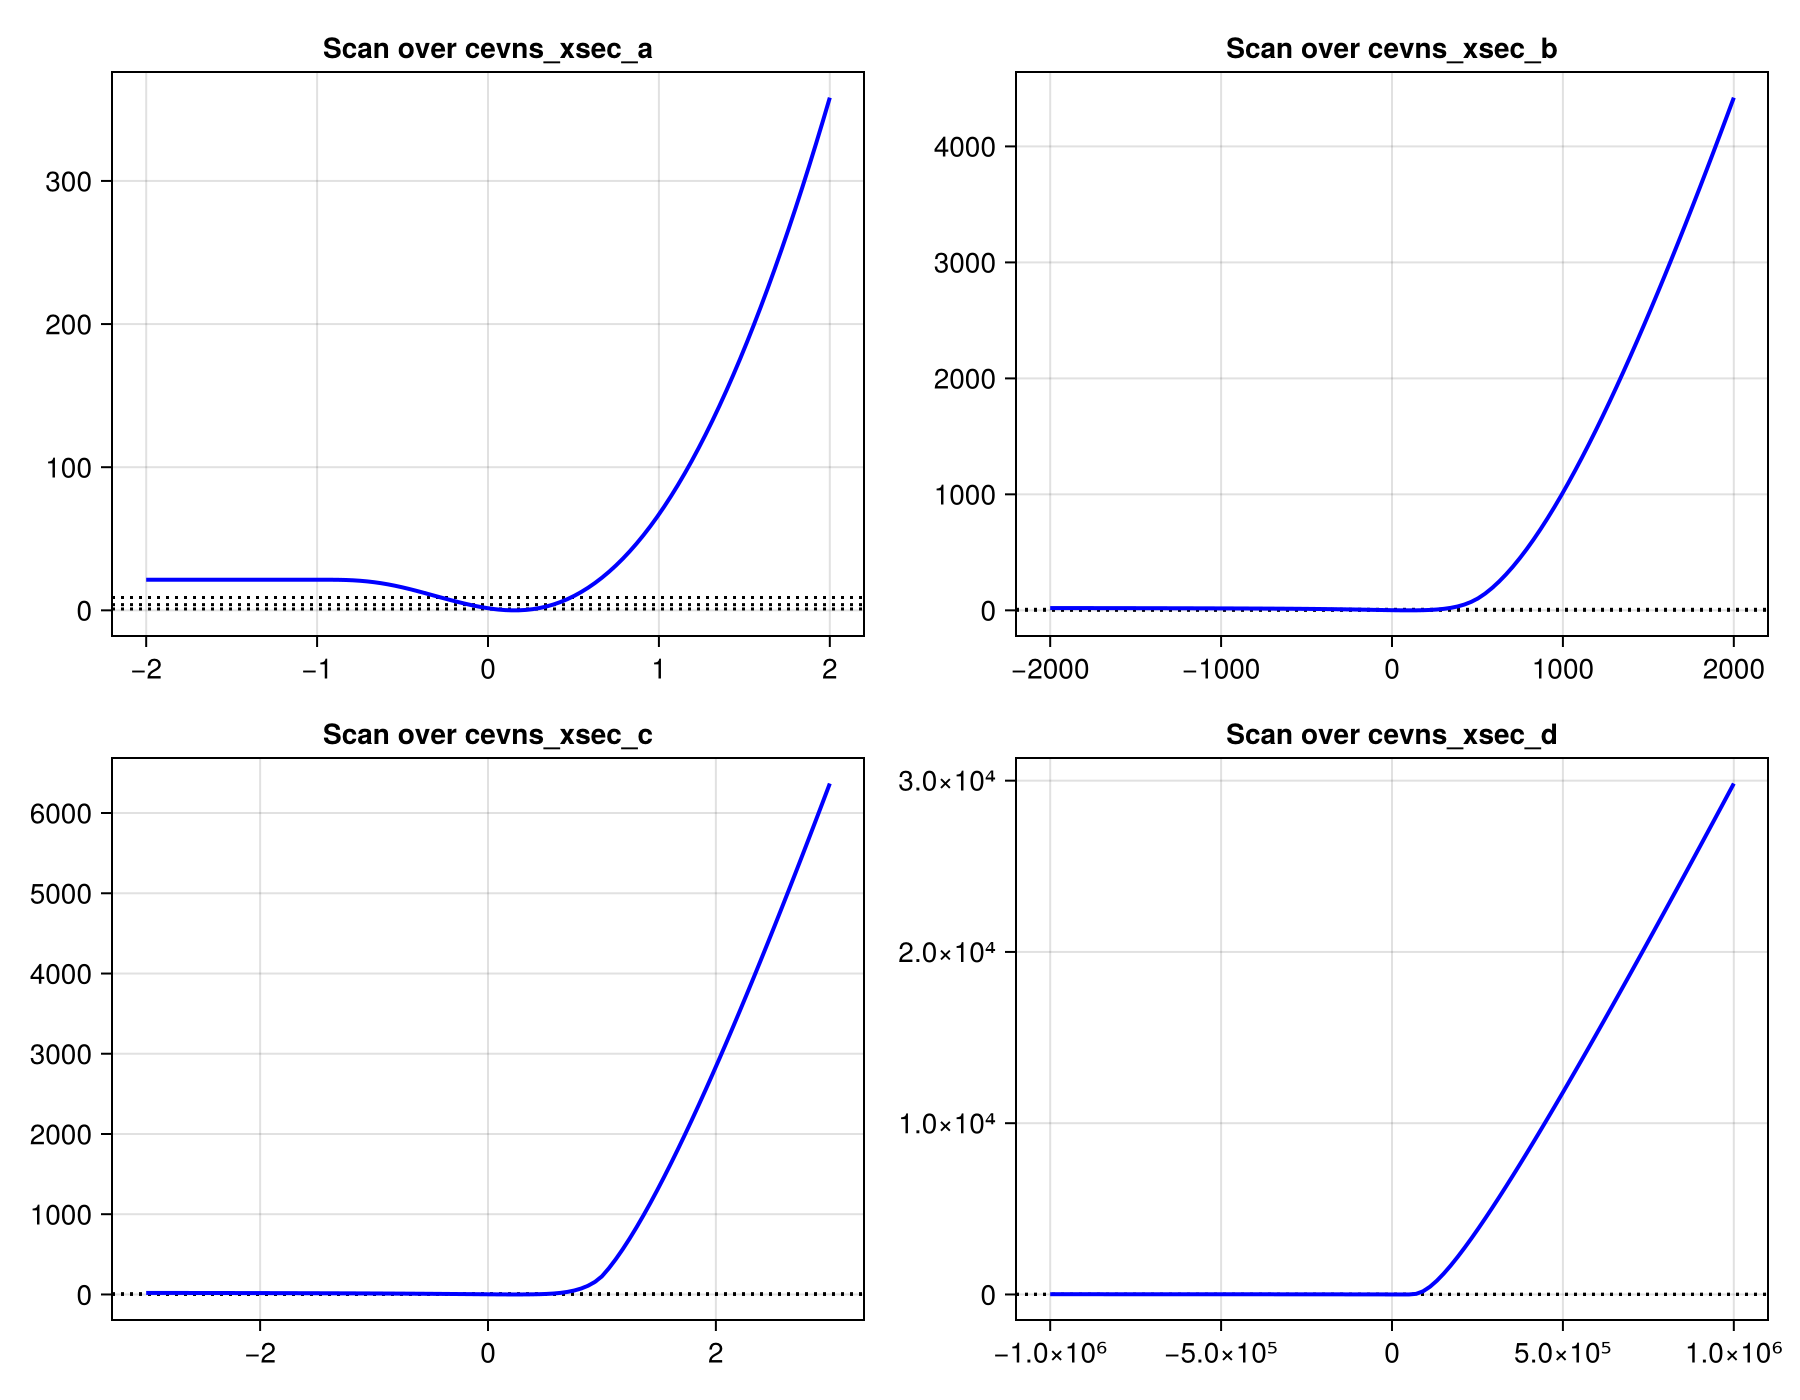

In [13]:
using CairoMakie
coherent_lAr = Newtrinos.coherent_lAr.configure()
experiments = (; coherent_lAr)

likelihood = Newtrinos.generate_likelihood(experiments)
p = Newtrinos.get_params(experiments)
priors = Newtrinos.get_priors(experiments)


scan_params = [
    (:cevns_xsec_a, 100, "Scan over cevns_xsec_a"),
    (:cevns_xsec_b, 100, "Scan over cevns_xsec_b"),
    (:cevns_xsec_c, 100, "Scan over cevns_xsec_c"),
    (:cevns_xsec_d, 100, "Scan over cevns_xsec_d"),
]

fig = Figure(resolution = (900, 700))

for (i, (param, npoints, label)) in enumerate(scan_params)
    row, col = fldmod1(i, 2)   # 2 columns grid
    ax = Axis(fig[row, col], title = label)

    scan_tuple = NamedTuple{(param,)}((npoints,))
    result = Newtrinos.scan(likelihood, priors, scan_tuple, p)

    CairoMakie.plot!(ax, result)  # uses the Newtrinos recipe
end

fig

In [14]:
using BAT
prior = distprod(;priors...)
bestfit = Newtrinos.find_mle(likelihood, prior, p)

┌ Info: Running Optimization for point 
└ @ Newtrinos /Users/heerakbanerjee/Documents/Newtrinos.jl/src/analysis/analysis_tools.jl:70


(-1748.3505781296985, -1774.2741334868967, (Rn_Ar = 4.121289031735132, cevns_xsec_a = -0.6343633066280934, cevns_xsec_b = -169.10887247545588, cevns_xsec_c = 1.4363862955916051, cevns_xsec_d = -77493.68422311638, coherent_lar_mass = 24.401292693589518, coherent_lar_qfa_a = 0.24596407512967156, coherent_lar_qfa_b = 0.0007803063914471962, delbrn_norm = 10.727011058600862, pbrn_norm = 551.6527669128344, sns_nu_per_POT = 0.0900763421307293, ss_bkg_norm = 3131.566927038472))